# tap.tune~ — the pitch corrector, measured

The full correction chain behind `tap.tune~` — YIN detection, scale/MIDI target mapping, the
retune-speed glide, and the three selectable resynthesis backends — driven as the **actual
shipping kernel** (`taptools/tune.h`) through the C ABI (`Tune` in `taptools_py`). Pitch tracks
are measured with the same shared DspTap detector the corrector itself uses (`Yin`).

Contents:

1. **Retune speed** — the primary musical control, from hard snap to transparent.
2. **The three backends compared** — `grain` / `psola` / `pvoc` on the same vibrato "voice":
   what each one is for, and what it costs in latency.
3. **Formant preservation** — the LPC option on the `pvoc` backend, holding a synthetic
   formant in place through a large MIDI-mode correction.

Deeper primitive-level material (why PSOLA thins pure tones, why the phase vocoder needs peak
locking) lives in the DspTap notebook `notebooks/pitchshift.ipynb` in the `tap/dsptap` repo.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import taptools_py as tap

plt.rcParams.update({
    "figure.dpi": 96, "figure.figsize": (9, 3.2),
    "axes.grid": True, "grid.alpha": 0.3,
})
C = tap.PALETTE

sr = 48000.0
HOP = 256

def saw(freq_or_track, seconds=None, harmonics=12):
    """Band-limited saw; freq may be a scalar or a per-sample frequency track."""
    if np.isscalar(freq_or_track):
        f = np.full(int(seconds * sr), float(freq_or_track))
    else:
        f = np.asarray(freq_or_track)
    phase = np.cumsum(f) / sr
    x = sum(np.sin(2 * np.pi * h * phase) / h for h in range(1, harmonics + 1))
    return x / np.abs(x).max()

def track_hz(x):
    """Pitch track (Hz, NaN where unvoiced) via the shared DspTap detector."""
    periods = tap.Yin().track(x, hop=HOP)
    hz = np.where(periods > 0, sr / np.maximum(periods, 1e-9), np.nan)
    t = (np.arange(len(hz)) * HOP + tap.Yin().frame_size) / sr
    return t, hz

def cents(f, ref):
    return 1200 * np.log2(f / ref)

## 1 · Retune speed: hard snap to transparent

A sawtooth held 46 cents sharp of A3 (226 Hz vs 220). The `speed` parameter is the exponential
time constant of the glide onto the target: 0 ms snaps instantly (the hard-quantize vocal
effect), 20 ms is classic tight correction, 200 ms corrects so slowly it reads as drift. This is
the one knob that takes the same machinery from transparent intonation repair to the signature
effect.

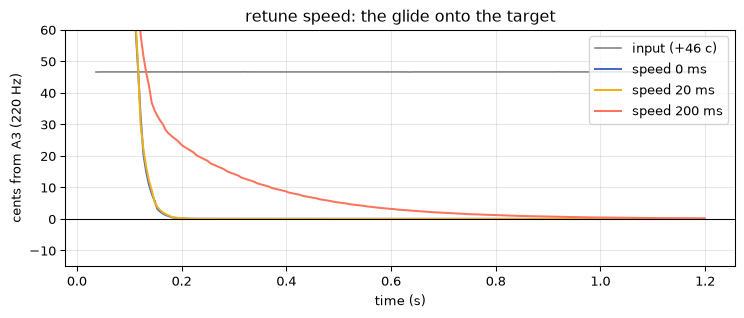

In [2]:
x = saw(226.0, seconds=1.2)

fig, ax = plt.subplots()
t_in, hz_in = track_hz(x)
ax.plot(t_in, cents(hz_in, 220.0), color="gray", lw=1.2, label="input (+46 c)")
for speed, color in [(0.0, C[0]), (20.0, C[1]), (200.0, C[2])]:
    c = tap.Tune(sr, speed=speed)  # defaults: chromatic, grain backend
    t, hz = track_hz(c.process(x))
    ax.plot(t, cents(hz, 220.0), color=color, label=f"speed {speed:g} ms")
ax.axhline(0, color="k", lw=0.8)
ax.set(xlabel="time (s)", ylabel="cents from A3 (220 Hz)", ylim=(-15, 60),
       title="retune speed: the glide onto the target")
ax.legend(loc="upper right")
plt.show()

## 2 · The three backends on the same "voice"

The detector, mapper, and glide are shared; only the resynthesis swaps (`set_backend`). The test
signal is a sawtooth "voice" wobbling ±40 cents around 226 Hz at 5 Hz — enough drift that hard
snapping quantizes it audibly. All three land the correction; they differ in *how* and in what
they cost:

| backend | method | character | latency @ 48 kHz |
|---|---|---|---|
| `grain` | two-tap delay-line, window period-locked | waveform-preserving, cheapest | a few ms |
| `psola` | TD-PSOLA (`tap::dsp::psola`) | formant-preserving on voice | ~36 ms (2× deepest period) |
| `pvoc` | peak-locked phase vocoder (`tap::dsp::pvoc`) | strongest on dense material | ~21 ms (one FFT frame) |

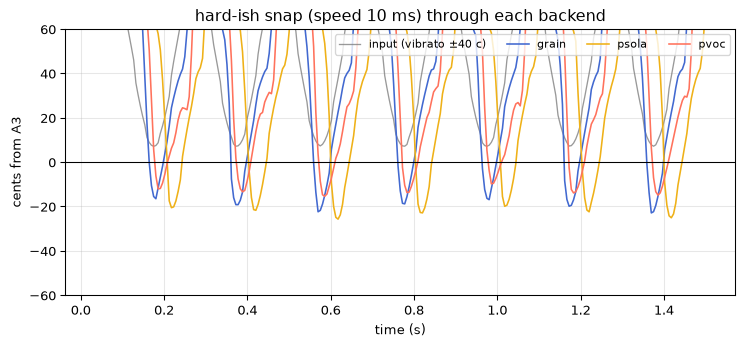

grain : settled output  220.00 Hz (target 220.00), tail peak 1.00


psola : settled output  220.00 Hz (target 220.00), tail peak 0.95


pvoc  : settled output  220.00 Hz (target 220.00), tail peak 0.97


In [3]:
t_samp = np.arange(int(1.5 * sr))
vibrato = 226.0 * 2 ** (0.40 / 12 * np.sin(2 * np.pi * 5.0 * t_samp / sr))  # ±40 cents
x = saw(vibrato)

fig, ax = plt.subplots(figsize=(9, 3.6))
t_in, hz_in = track_hz(x)
ax.plot(t_in, cents(hz_in, 220.0), color="gray", lw=1.0, alpha=0.8, label="input (vibrato ±40 c)")
for backend, color in [("grain", C[0]), ("psola", C[1]), ("pvoc", C[2])]:
    c = tap.Tune(sr, speed=10.0, backend=backend)
    t, hz = track_hz(c.process(x))
    ax.plot(t, cents(hz, 220.0), color=color, lw=1.2, label=backend)
ax.axhline(0, color="k", lw=0.8)
ax.set(xlabel="time (s)", ylabel="cents from A3", ylim=(-60, 60),
       title="hard-ish snap (speed 10 ms) through each backend")
ax.legend(loc="upper right", ncols=4, fontsize=8)
plt.show()

for backend in ("grain", "psola", "pvoc"):
    c = tap.Tune(sr, speed=0.0, backend=backend)
    y = c.process(saw(226.0, seconds=1.0))
    tail = y[-int(0.3 * sr):]
    p = tap.Yin().track(tail, hop=HOP)
    p = p[p > 0]
    print(f"{backend:6s}: settled output {sr / np.median(p):7.2f} Hz "
          f"(target 220.00), tail peak {np.abs(tail).max():.2f}")

All three tracks sit on the same corrected line — the differences are in the resynthesis
character (and latency), not the intonation. Note the small onset offsets between the tracks:
that is each backend's latency made visible (grain ≈ ms, pvoc = 1024 samples, psola ≈ 1750
samples at 48 kHz).

## 3 · Formant preservation on the `pvoc` backend

Corrections of a few cents don't move formants audibly, but MIDI mode can command *large*
shifts — the chipmunk regime. `set_formant(true)` enables the LPC source-filter option on the
phase-vocoder backend (see `tap/dsp/pvoc.h`): the excitation shifts, the envelope stays. The
`psola` backend needs no flag (envelope preservation is its resampling rule); the `grain` engine
is waveform-preserving, the right default for small corrections.

Test: a 240 Hz "voice" with a synthetic formant bump at 960 Hz, corrected in MIDI mode to a held
E4 (329.6 Hz — a 5.5-semitone jump).

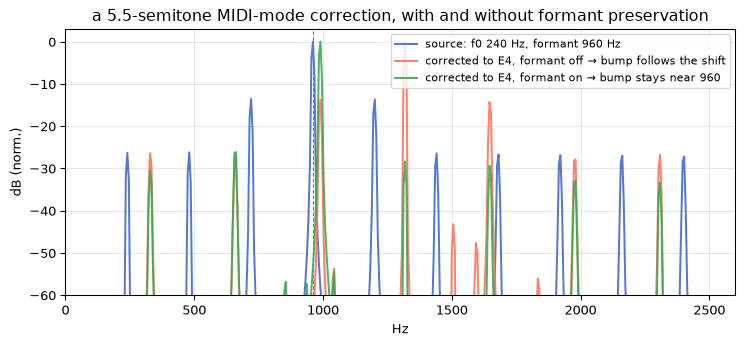

formant off: energy 800–1150 Hz / 1200–1600 Hz =    0.05
formant on : energy 800–1150 Hz / 1200–1600 Hz =  730.42


In [4]:
def formant_voice(f0=240.0, center=960.0, seconds=1.5):
    t = np.arange(int(seconds * sr))
    x = sum((np.exp(-(((f0 * h) - center) / 180.0) ** 2) + 0.05)
            * np.sin(2 * np.pi * f0 * h * t / sr) for h in range(1, 17))
    return x / np.abs(x).max()

def spectrum_db(x, n=8192):
    X = np.abs(np.fft.rfft(x[-n:] * np.hanning(n)))
    return np.fft.rfftfreq(n, 1 / sr), 20 * np.log10(np.maximum(X / X.max(), 1e-6))

src = formant_voice()
outs = {}
for formant in (False, True):
    c = tap.Tune(sr, speed=0.0, mode="midi", backend="pvoc", formant=formant)
    c.note_on(64)  # E4
    outs[formant] = c.process(src)

fig, ax = plt.subplots(figsize=(9, 3.6))
for x_, name, color in [(src, "source: f0 240 Hz, formant 960 Hz", C[0]),
                        (outs[False], "corrected to E4, formant off → bump follows the shift", C[2]),
                        (outs[True], "corrected to E4, formant on → bump stays near 960", C[4])]:
    f, S = spectrum_db(x_)
    ax.plot(f, S, color=color, alpha=0.9, label=name)
ax.axvline(960, color="gray", lw=0.8, ls="--")
ax.set(xlim=(0, 2600), ylim=(-60, 3), xlabel="Hz", ylabel="dB (norm.)",
       title="a 5.5-semitone MIDI-mode correction, with and without formant preservation")
ax.legend(loc="upper right", fontsize=8)
plt.show()

def band(x_, lo, hi, n=8192):
    X = np.abs(np.fft.rfft(x_[-n:] * np.hanning(n))) ** 2
    f = np.fft.rfftfreq(n, 1 / sr)
    return X[(f >= lo) & (f <= hi)].sum()

for formant, y in outs.items():
    label = "formant on " if formant else "formant off"
    print(f"{label}: energy 800–1150 Hz / 1200–1600 Hz = {band(y, 800, 1150) / band(y, 1200, 1600):7.2f}")

## Summary

- **Retune speed** is the character control: 0 ms = the hard-snap effect, tens of ms =
  transparent correction, hundreds of ms = drift repair only.
- The **three backends** share detection, mapping, and glide, and all land the same intonation;
  choose by material and latency budget — `grain` (default, cheapest, waveform-preserving),
  `psola` (voice, formant-preserving), `pvoc` (dense material, plus the `formant` option for
  large corrections).
- Every figure above is the shipping `tune.h` kernel driven through `tools/capi`; the hard
  gates live in `tests/tune_test.cpp` (kernel) and the DspTap primitive batteries.